In [ ]:
import sys
import yaml
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
root = Path.cwd().parent.parent
sys.path.append(str(root))
plt.rcParams.update({"text.usetex": True, "font.family": "Computer Modern"})

from train import Trainer
from configs.materials import materials
from data.data_set import DataSet
from utils.readable import dataset_latex

figure_path = Path('/mnt/c/users/rdsup/desktop/1st-paper/figures')

with open(root / "configs" / "generators.yaml", "r") as f:
    config = yaml.safe_load(f)

with open(root  / "data" / "data_sets.yaml" , "r") as f:
    datasets = yaml.safe_load(f)

train_inp_names = datasets["train"]
eval_rand_inp_names = datasets["eval"]["rand"]
eval_crit_inp_names = datasets["eval"]["crit"]
mat_names = materials.keys()

In [2]:
def find_model_dir(directory, prefix='MLP-incr-3-5-3'):
    return [f for f in Path(directory).iterdir() if f.is_dir() and f.name.startswith(prefix)][0]

def pred_vs_truth(model, mat_name, eval_inp_name, inp_type, n=1):
    
    dataset = DataSet(mat_name, inp_type, eval_inp_name, data_path=root/'data')

    u_list, y_t_list = dataset.u_list, dataset.y_list

    S, T, F = u_list.shape

    if S < n:
        print(f'In {eval_inp_name} set, we have just {S} samples!')
        n = S

    k = model.k
    y_p_list = model.rollout(u_list,y_t_list[:,:k,:])

    y_p_list = y_p_list.detach().numpy()
    y_t_list = y_t_list.detach().numpy()

    print(f'{dataset.inp_name}: {((y_p_list - y_t_list)**2).mean()**(1/2)/1e6}')

    return u_list, y_t_list, y_p_list

impulse: 10.871076071434327
cyclic: 214469.26221299366
resolution: 2474252.294028744


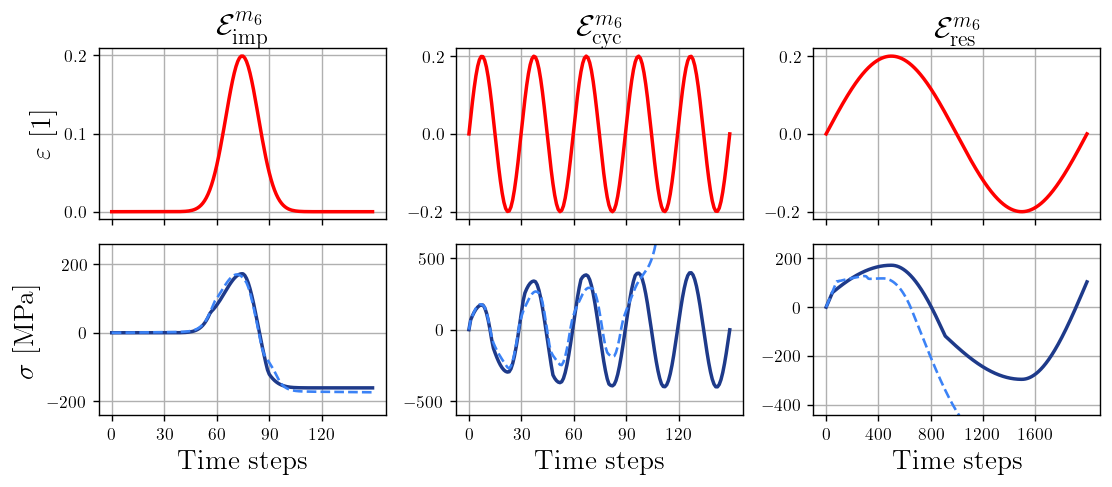

In [3]:
mat_name = 'mixed-armstrong-fredrick'
train_inp_name = 'bl_ms_42_200'
inp_names = ['impulse', 'cyclic','resolution']

model_dir = find_model_dir(root / 'metrics' / mat_name / train_inp_name)
state_dict = Trainer.load_state_dict_from_path(model_dir / 'model.pth')
model = Trainer.load_model(state_dict)



fig, ax = plt.subplots(2, len(inp_names), figsize=(3*len(inp_names), 4),dpi=125)

for i, inp_name in enumerate(inp_names):
    
    u, yt, yp = pred_vs_truth(model, mat_name, inp_name, 'eval', n=1)
    u = u[0,:,0]
    yt = yt[0,:,0]/1e6
    yp = yp[0,:,0]/1e6

    ax[0,i].set_title(dataset_latex('eval', inp_name, mat_name=mat_name), fontsize=18)
    ax[0,i].plot(u, 'r-', label='truth',lw=2)
    ax[0,i].set_xticklabels([])
    ax[0,i].grid()
    ax[1,i].plot(yt, ls='-', c='#1e3a8a', label='truth',lw=2)
    ax[1,i].plot(yp, ls='--', c='#3b82f6', label='pred',lw=1.5)
    ax[1,i].set_ylim(yt.min()*1.5,yt.max()*1.5)
    ax[1,i].set_xlabel(rf'Time steps', fontsize=16)
    ax[1,i].grid()
    
    ax[0,i].set_xticks([i for i in range(0, len(u), len(u)//5)])
    ax[1,i].set_xticks([i for i in range(0, len(u), len(u)//5)])
    
    

ax[0,0].set_ylabel(rf'$\varepsilon$ [1]', fontsize=16)
ax[1,0].set_ylabel(rf'$\sigma$ [MPa]', fontsize=16)
plt.tight_layout()

plt.savefig(figure_path / f'examples.svg',format='svg', bbox_inches='tight')
plt.savefig(figure_path / f'examples.pdf', bbox_inches='tight')

plt.show()